# Practical 6

The following is concerned with the Median prices of the houses and some related factors in a particular city. 
The following describes the dataset columns:   
**CRIM** - per capita crime rate by town.  
**ZN** proportion of residential land zoned for lots over 25,000 sq. ft.  
**INDUS** - proportion of non-retail business acres per town.  
**RIVER** - River dummy variable (1 if tract bounds river; 0 otherwise)  
**NOX** - nitric oxides concentration (parts per 10 million)  
**RM**- average number of rooms per dwelling    
**AGE**- proportion of owner-occupied units built prior to 2000  
**DIS** - weighted distances to five employment centres  
**RAD** - index of accessibility to radial highways  
**TAX** - full-value property-tax rate per 10,000    
**PTRATIO** - pupil-teacher ratio by town   
**LSTAT** - % lower status of the population   
**PRICE** - Median value of owner-occupied homes in $1000's    

To apply suitable data preprocessing tools and machine learning algorithms along with different model performance improvement strategies to the data set. 
The objective is to provide explanation and prediction of the “Median Prices” of the houses.  Also provide some suitable workable suggestions to the buyers/sellers based on the analysis of the data.

In [1]:
# importing libraries
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

# importing subpackage of matplotlib
import matplotlib.pyplot as plt

# importing seaborn for visualization
import seaborn as sns 

# import train-test split 
from sklearn.model_selection import train_test_split

# import function to perform linear regression using OLS
import statsmodels.api as sm

# 'metrics' from sklearn is used for evaluating the model performance
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score, mean_absolute_error

# import function to perform linear regression
from sklearn.linear_model import LinearRegression

# Import KFold for K-Fold Cross Validation 
# and cross_val_score for evaluating model performance
from sklearn.model_selection import KFold, cross_val_score

# import StandardScaler to perform scaling
from sklearn.preprocessing import StandardScaler 

# import SGDRegressor from sklearn to perform linear regression with stochastic gradient descent
from sklearn.linear_model import SGDRegressor

# import function for ridge regression
from sklearn.linear_model import Ridge

# import function for lasso regression
from sklearn.linear_model import Lasso

# import function for elastic net regression
from sklearn.linear_model import ElasticNet

# import function to perform GridSearchCV
from sklearn.model_selection import GridSearchCV

In [4]:
# loading the csv file
data = pd.read_csv("Practical 6 Data.csv")

# displaying the first five records 
data.head()

,CRIM,ZN,INDUS,RIVER,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,NaN,36.2


In [5]:
# using info() to understand the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   RIVER    486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    486 non-null    float64
 12  PRICE    506 non-null    float64
dtypes: float64(11), int64(2)
memory usage: 51.5 KB


# Data Preparation
Do data Preparation because machine learning models cannot learn properly from messy or inconsistent data.      
It helps improve the accuracy, efficiency, and reliability of the model by making the data clean, complete, and suitable for analysis.

In [86]:
# finding the number of null values in the data
data.isnull().sum()

CRIM       20
ZN         20
INDUS      20
RIVER      20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
LSTAT      20
PRICE       0
dtype: int64

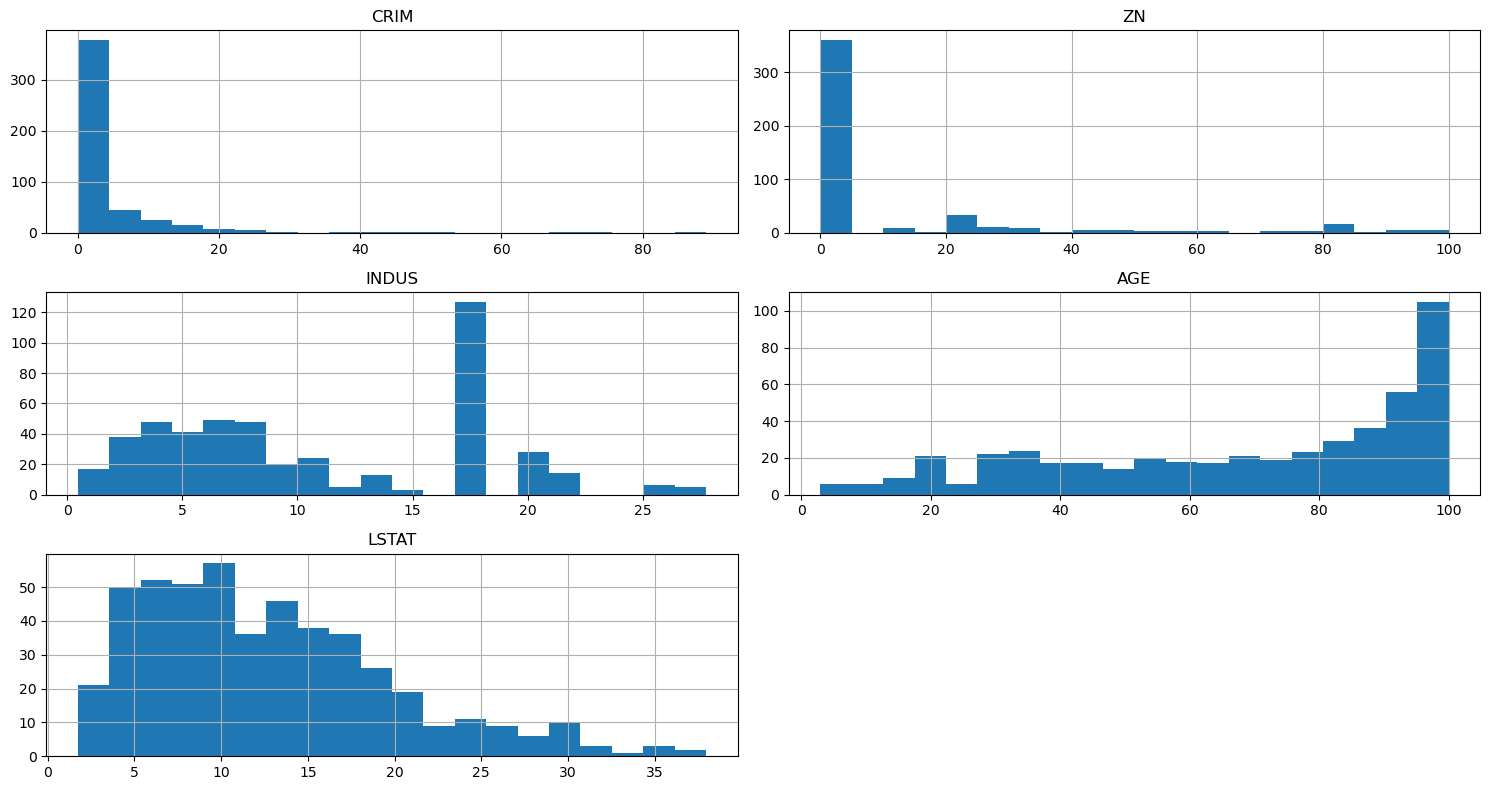

In [87]:
# extract all the numerical variables with missing values in a new dataframe 'df_missing_values'
data_missing_values = data[['CRIM','ZN','INDUS','AGE','LSTAT']]

# plot histogram of all variables which have missing values
# set the number of bins to 20
# set the figure size using 'figsize'
data_missing_values.hist(bins = 20, figsize = (15,8))

# adjust the subplots
plt.tight_layout()

# display the plot
plt.show()

In [88]:
# We also use the describe() method to understand the data distribution and decide which central value (mean, median, or mode) 
# should be used to fill missing values.
data.describe()

,CRIM,ZN,INDUS,RIVER,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,PRICE
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


### Handling Missing values

In [89]:
# impute skewed variables with median
data['CRIM'] = data['CRIM'].fillna(data['CRIM'].median())
data['ZN'] = data['ZN'].fillna(data['ZN'].median())
data['INDUS'] = data['INDUS'].fillna(data['INDUS'].median())
data['AGE'] = data['AGE'].fillna(data['AGE'].median())
data['LSTAT'] = data['LSTAT'].fillna(data['LSTAT'].mean())

In [90]:
# Converting the 'RIVER' column data type into categorical/object type
data['RIVER'] = data['RIVER'].astype('object')
data['RIVER'].value_counts()

RIVER
0.0    452
1.0     34
Name: count, dtype: int64

In [91]:
# Converting categorical 'RIVER' values into numerical dummy variables
data['RIVER'] = pd.get_dummies(data = data['RIVER'], drop_first=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   RIVER    506 non-null    bool   
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  PRICE    506 non-null    float64
dtypes: bool(1), float64(10), int64(2)
memory usage: 48.1 KB


In [92]:
# Filling missing values in 'RIVER' column using the mode (most frequent value)
data['RIVER'] = data['RIVER'].fillna(data['RIVER'].mode()[0])

In [93]:
# Convert the 'RIVER' column data type to float
data['RIVER'] = data['RIVER'].astype('float')

# Display summary information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   RIVER    506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  LSTAT    506 non-null    float64
 12  PRICE    506 non-null    float64
dtypes: float64(11), int64(2)
memory usage: 51.5 KB


In [94]:
# Checking whether the null values are still there in the data
data.isnull().sum()

CRIM       0
ZN         0
INDUS      0
RIVER      0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
LSTAT      0
PRICE      0
dtype: int64

**After completing data preparation and preprocessing**       
**We now build models on the prepared dataset.**

# Linear Regression 
#### Build a full model on the given data

# Data Standardization and Train-Test Split

Before applying the machine learning models, the predictor variables are standardized and the dataset is divided into training and testing subsets.


Although standardization is not compulsory for Multiple Linear Regression, it is also applied to the Linear Regression model so that all models are trained and evaluated on the same processed dataset. This ensures a fair and consistent comparison among the different models and provides a true picture of their predictive performance.


Standardization is especially important for models such as Gradient Descent, Ridge Regression, LASSO Regression, and Elastic Net Regression, as these methods are sensitive to the scale of the variables.


The same standardized train-test split is therefore used for all models to identify the model that performs best for predicting housing prices.


In [104]:
# Select the independent variables (features)
X = data.iloc[:, :12]

# Convert all feature values to float type
X = X.astype("float")

# Select the dependent variable (target)
y = data['PRICE']

# initialize the standard scalar
X_scaler = StandardScaler()


X = X_scaler.fit_transform(X)

# standardize the target explicitly and storing it in a new variable 'y'
y = (y - y.mean()) / y.std()

# Split the dataset into training and testing sets
# test_size = 0.2 means 20% data is used for testing
# random_state ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=10, test_size=0.2
)


In [105]:
# initiate linear regression model
linreg = LinearRegression()

# build the model using train data
# use fit() to fit the regression model
MLR_model = linreg.fit(X_train, y_train)

# For training set:
# train_pred: prediction made by the model on the training dataset 'X_train'
# y_train: actual values ofthe target variable for the train dataset
 
# predict the output of the target variable from the train data 
train_pred = MLR_model.predict(X_train)

# calculate the MSE using the "mean_squared_error" function
# MSE for the train data
mse_train = mean_squared_error(y_train, train_pred)

# print the MSE for the train set
print("MSE for Train Data:", mse_train)
    
# For testing set:
# test_pred: prediction made by the model on the test dataset 'y_train'
# y_test: actual values of the target variable for the test dataset
 
# predict the output of the target variable from the test data
test_pred = MLR_model.predict(X_test)

# MSE for the test data
mse_test = mean_squared_error(y_test, test_pred)

# print the MSE for the test set
print("MSE for Test Data:", mse_test)

MSE for Train Data: 0.24377736485570808
MSE for Test Data: 0.42755660710393867


The OLS model gives a Mean Squared Error of 0.244 on the training data
and 0.4225 on the testing data.

Since the testing error is higher than the training error, the model
shows slight overfitting.

**Cross Validation**

Cross-validation is performed after OLS to evaluate whether the model performs consistently on different subsets of the data.
It helps to detect overfitting and provides a more reliable estimate of prediction accuracy than a single train-test split.

In [106]:
# Perform 10-Fold Cross Validation to evaluate model performance

# Create a Linear Regression model
model = LinearRegression()

# Define K-Fold Cross Validation
# n_splits=10 means the data is divided into 10 parts
# shuffle=True randomly shuffles the data before splitting
# random_state ensures reproducibility
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Perform cross-validation using R² score as the evaluation metric
scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

# Display R² score for each fold
print("R² scores for each fold:", scores)

# Display the average R² score across all folds
print("Average R² score:", np.mean(scores))

R² scores for each fold: [0.78051295 0.59743541 0.76466703 0.70648278 0.58491374 0.79261581
 0.72204053 0.77983494 0.69598412 0.61103986]
Average R² score: 0.7035527181989749


# Interpretation of Linear Regression Model

There does not appear to be strong overfitting.

Our train and test MSE were:

Train MSE = 0.24374
Test MSE = 0.42122

The test error is higher than the train error, so there is some slight overfitting, but not severe.

Also, your 10-fold cross-validation average R^2 is about 0.704, and the fold scores are fairly consistent (roughly 0.58 to 0.79). That consistency suggests the model generalizes reasonably well and is not heavily overfitting.

But we can use other model as well

## Gradient Descent
Gradient descent is another method of estimating regression coefficients. 
OLS gives the exact coefficient values directly, whereas gradient descent reaches similar values iteratively by minimizing the error function.
Here I have applied Full Model Gradient Descent

In [107]:
# Select the independent variables (features)
X = data.iloc[:, :12]

# Select the dependent variable (target)
y = data['PRICE']

# Initialize the StandardScaler for feature scaling
X_scaler = StandardScaler()

# Standardize all feature variables to bring them to a common scale
X = X_scaler.fit_transform(X)

# Standardize the target variable using Z-score normalization
y = (y - y.mean()) / y.std()

# Split the dataset into training and testing sets
# test_size = 0.2 means 20% data is used for testing
# random_state ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split( X, y, random_state=10, test_size=0.2)

## Hyperparameter Tuning of Learning Rate using Grid Search

In [108]:
# Hyperparameter Tuning using Full Batch Gradient Descent

# Instantiate the SGDRegressor model
# max_iter defines the maximum number of iterations
# tol specifies the stopping criterion
# penalty=None means no regularization is applied
# learning_rate='constant' keeps the learning rate fixed during training
sgd = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, learning_rate='constant', random_state=42)

# Define the hyperparameter grid
# eta0 represents the learning rate in SGDRegressor
param_grid = {'eta0': np.linspace(0.001, 1.0, 10)}

# Perform Grid Search with 5-Fold Cross Validation
# scoring='neg_mean_squared_error' evaluates model performance using MSE
grid_search = GridSearchCV(estimator=sgd, param_grid=param_grid, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

# Fit the grid search model on the training data
grid_search.fit(X_train, y_train)

# Display the best hyperparameters obtained
print("Best parameters found:", grid_search.best_params_)
print("Best learning rate:", grid_search.best_params_)

# Select the best model from Grid Search
best_model = grid_search.best_estimator_

# Predict target values using the test data
y_pred = best_model.predict(X_test)

# Evaluate model performance on the test set using Mean Squared Error
print("\nTest set evaluation:")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Best parameters found: {'eta0': np.float64(0.001)}
Best learning rate: {'eta0': np.float64(0.001)}

Test set evaluation:
Mean Squared Error: 0.40942842556371845


In [109]:
# Full model using Full Batch Gradient Descent

# Instantiate the SGDRegressor model
# learning_rate='constant' keeps the learning rate fixed at eta0 for every iteration
# eta0 specifies the learning rate value
# random_state ensures reproducibility of results

# Other learning rate options:
# 'invscaling'  : gradually decreases the learning rate over time
# 'adaptive'   : decreases the learning rate only when improvement stops
# 'optimal'    : automatically chooses the learning rate

sgd = SGDRegressor(learning_rate='constant', eta0=0.001,random_state=1)

# Train the Gradient Descent model using the training data
linreg_with_SGD = sgd.fit(X_train, y_train)

# Predict target values for the training dataset
y_pred_train = linreg_with_SGD.predict(X_train)

# Predict target values for the testing dataset
y_pred_test = linreg_with_SGD.predict(X_test)

# Calculate Mean Squared Error (MSE) for training data
mse_train = mean_squared_error(y_train, y_pred_train)
print("MSE for Train Data:", mse_train)

# Calculate Mean Squared Error (MSE) for testing data
mse_test = mean_squared_error(y_test, y_pred_test)
print("MSE for Test Data:", mse_test)

MSE for Train Data: 0.2506542582163039
MSE for Test Data: 0.4126429306152011


#### Interpretation
After tuning the learning rate using Grid Search, the full-batch gradient descent model achieved a training MSE of 0.2507 and a testing MSE of 0.4126.
Since the testing error is only slightly greater than the training error, the model does not show significant overfitting and performs well on unseen data.

In [110]:
print("Intercept:", linreg_with_SGD.intercept_)
print("Coefficients:", linreg_with_SGD.coef_)

Intercept: [-0.02126379]
Coefficients: [-0.10827576  0.10090674 -0.07186305  0.07820823 -0.12609099  0.27808005
  0.00513777 -0.25380475  0.08992966 -0.0775667  -0.16779983 -0.41112505]


The intercept represents the predicted value of PRICE when all independent variables are zero.
The coefficients represent the change in PRICE for a one-unit increase in the corresponding feature, keeping all other variables constant.

Positive coefficient -> PRICE increases as that feature increases.    
Negative coefficient -> PRICE decreases as that feature increases. 

The fitted regression equation is given above.

## Examining the correlation among features in the linear regression model

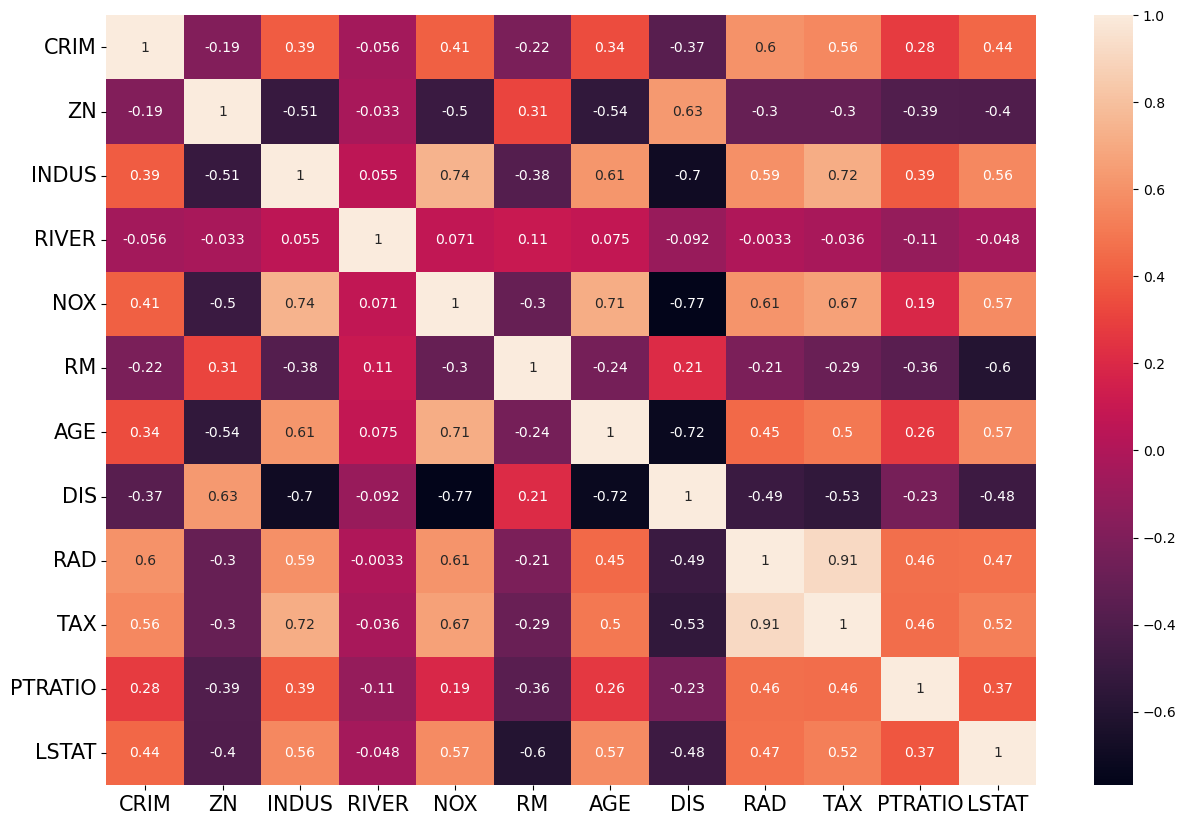

In [111]:
# set dimensions for the plot figure
fig_dims = (15,10)
fig, ax = plt.subplots(figsize=fig_dims)

# create a copy of dataframe
df_features = data.iloc[:,:12]

# plot the heat map
# corr: give the correlation matrix
# annot: prints the correlation values in the chart
# annot_kws: sets the font size of the annotation
sns.heatmap(df_features.corr(), annot = True, annot_kws = {"size": 10})

# rotate the y-axis labels
# set text size using 'fontsize'
plt.yticks(rotation = 'horizontal', fontsize = 15)
plt.xticks(fontsize = 15)

# display the plot
plt.show()

# Regularization
As multicollinearity is detected, regularization is commonly used because highly correlated predictors make the OLS coefficients unstable.

With multicollinearity:

* coefficients can become very large
* signs of coefficients may change unexpectedly
* small changes in data can greatly change the estimates

Regularization reduces this problem by shrinking the coefficients.

The most common methods are:

* Ridge Regression for multicollinearity
* LASSO if you also want feature selection
* Elastic Net when predictors are highly correlated and you want both shrinkage and selection

## 1) Ridge Regression
Performing the regression analysis without eliminating features involved in multicollinearity detected above in heatmap. Used Ridge Regression with tuned alpha

In [6]:
# selecting the independent variables 
X = data.iloc[:,:12]

# set the dependent variable
y = data['PRICE']

# initializing the standard scalar
X_scaler = StandardScaler()

# standardizing all the columns of df_ipl
X = X_scaler.fit_transform(X)

# standardizing the target explicitly and storing it in a new variable 'y'
y = (y - y.mean()) / y.std()

# split data into train subset and test subset
# set 'random_state' to generate the same dataset each time you run the code 
# 'test_size' returns the proportion of data to be included in the testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=110, test_size = 0.2)

### Grid Search for Ridge Regression  
Grid Search is used in Ridge Regression to determine the optimal value of alpha.
The selected alpha gives the best balance between model fit and coefficient shrinkage, thereby improving prediction accuracy and reducing multicollinearity.

The value of α controls how much the coefficients are shrunk:
* Small α → model behaves like OLS  
* Large α → coefficients shrink more strongly

Grid search tries many possible values of α

In [113]:
# create a dictionary with hyperparameters and its values
tuned_paramater = [{'alpha':np.linspace(0.1,100,1000)}]
 
# instantiate the Ridge() method
ridge = Ridge()

# using GridSearchCV to find the optimal value of alpha
# estimator: pass the ridge regression model
# param_grid: pass the list 'tuned_parameters'
# cv: number of folds in k-fold i.e. here cv = 10
grid = GridSearchCV(estimator = ridge, 
                          param_grid = tuned_paramater, 
                          cv = 10)

# fit the model on X_train and y_train
grid.fit(X_train, y_train)

# get the best parameters
print('Best parameters for Ridge Regression: ',grid.best_params_)

Best parameters for Ridge Regression:  {'alpha': np.float64(19.000000000000004)}


In [114]:
# use Ridge() to perform ridge regression
# 'alpha' assigns the regularization strength to the model
ridge = Ridge(alpha = 19)

# fit the model on train set using fit()
ridge_model = ridge.fit(X_train, y_train)

# For training set:
# train_pred: prediction made by the model on the training dataset 'X_train'
# y_train: actual values ofthe target variable for the train dataset
 
# predict the output of the target variable from the train data 
train_pred = ridge_model.predict(X_train)

# calculate the MSE using the "mean_squared_error" function
# MSE for the train data
mse_train = mean_squared_error(y_train, train_pred)

# print the MSE for the train set
print("MSE for Train Data: ", mse_train)
    
# For testing set:
# test_pred: prediction made by the model on the test dataset 'y_train'
# y_test: actual values of the target variable for the test dataset
 
# predict the output of the target variable from the test data
test_pred = ridge_model.predict(X_test)

# MSE for the test data
mse_test = mean_squared_error(y_test, test_pred)

# print the MSE for the test set
print("MSE for Test Data:", mse_test)

MSE for Train Data:  0.2991581230314372
MSE for Test Data: 0.18727250039216373


#### Interpretation after alpha = 19
Grid Search selected alpha = 19 as the optimal regularization parameter for Ridge Regression.
Using this value, the Ridge model produced a Mean Squared Error of 0.2992 on the training data and 0.1873 on the testing data.

Before grid search, your Ridge Regression MSE values were:

* Train MSE = 0.2965
* Test MSE = 0.1928

After grid search with α=19:

* Train MSE = 0.2992
* Test MSE = 0.1873

So the training MSE increased slightly, but the testing MSE decreased.

This means the model fits the training data a little less closely, but performs better on unseen data. That is generally a good sign because the tuned Ridge model generalizes better.

In [115]:
ridge_model.coef_

array([-0.10029124,  0.09801523, -0.06059286,  0.0925856 , -0.19555811,
        0.2931788 , -0.01359603, -0.31505578,  0.13411934, -0.10770126,
       -0.2181143 , -0.36806941])

## 2) LASSO REGRESSION

## Hyperparameter Tuning of Alpha in LASSO Regression using Grid Search

In [116]:
# 'alpha' assigns the regularization strength to the model
tuned_paramaters = [{'alpha':np.linspace(0.1,100,1000)}]
 
# instantiate the Lasso() method
lasso = Lasso()

# use GridSearchCV() to find the optimal value of alpha
# estimator: pass the lasso regression model
# param_grid: pass the list 'tuned_parameters'
# cv: number of folds in k-fold i.e. here cv = 10
lasso_grid = GridSearchCV(estimator = lasso, 
                          param_grid = tuned_paramaters, 
                          cv = 10)

# fit the model on X_train and y_train using fit()
lasso_grid.fit(X_train, y_train)

# get the best parameters
print('Best parameters for Lasso Regression:', lasso_grid.best_params_)

Best parameters for Lasso Regression: {'alpha': np.float64(0.1)}


In [117]:
# use Lasso() to perform lasso regression
# 'alpha' 0.1 used as this was the best parameter value
lasso = Lasso(alpha = 0.1)

# fit the model on train set using fit()
lasso_model = lasso.fit(X_train, y_train)

# For training set:
# train_pred: prediction made by the model on the training dataset 'X_train'
# y_train: actual values ofthe target variable for the train dataset
 
# predict the output of the target variable from the train data 
train_pred = lasso_model.predict(X_train)

# calculate the MSE using the "mean_squared_error" function
# MSE for the train data
mse_train = mean_squared_error(y_train, train_pred)

# print the MSE for the train set
print("MSE for Train Data:", mse_train)
    
# For testing set:
# test_pred: prediction made by the model on the test dataset 'y_train'
# y_test: actual values of the target variable for the test dataset
 
# predict the output of the target variable from the test data
test_pred = lasso_model.predict(X_test)

# MSE for the test data
mse_test = mean_squared_error(y_test, test_pred)

# print the MSE for the test set
print("MSE for Test Data:", mse_test)

MSE for Train Data: 0.37016563486721776
MSE for Test Data: 0.20296676056177965


## Interpretation of the Result

Grid Search selected alpha = 0.1 as the optimal regularization parameter for the LASSO model.

The LASSO Regression model produced a Mean Squared Error (MSE) of 0.3702 on the training data and 0.2030 on the testing data.

The testing error is lower than the training error, indicating that the model does not suffer from overfitting and generalizes well to unseen data.

The relatively small MSE values suggest that the model fits the standardized dataset effectively and provides good predictive performance.

Since LASSO Regression also performs feature selection by shrinking less important coefficients toward zero, the model may additionally help in identifying the most influential predictors in the dataset.

Overall, the LASSO model performs satisfactorily, though comparison with other models such as Ridge Regression can help determine the best-performing model for the dataset.

In [118]:
lasso_model.coef_

array([-0.02237783,  0.        , -0.        ,  0.02334135, -0.        ,
        0.31211987, -0.        , -0.        , -0.        , -0.        ,
       -0.16812995, -0.37139417])

In [119]:
# create a dataframe to store the variable names and their corresponding coefficient values
# pass the dictionary as data to the dataframe
# 'coef_' returns the value of each coefficient
df_lasso_coeff = pd.DataFrame(data = {'Variable': df_features.columns, 'Coefficient': lasso_model.coef_})

# print the variables having the coefficient equal to zero
# 'to_list()' converts the output to the list type
print('Insignificant variables obtained from Lasso Regression when  alpha is 0.1 which is the best parameter value:',
      df_lasso_coeff.Variable[df_lasso_coeff.Coefficient == 0].to_list())

Insignificant variables obtained from Lasso Regression when  alpha is 0.1 which is the best parameter value: ['ZN', 'INDUS', 'NOX', 'AGE', 'DIS', 'RAD', 'TAX']


### Interpretation

After tuning the LASSO Regression model using Grid Search, the optimal regularization parameter was found to be alpha = 0.1.

Using this tuned value, the variables ZN, INDUS, NOX, AGE, DIS, RAD, and TAX obtained zero coefficients and were therefore treated as insignificant variables by the model.

This means that LASSO Regression removed these predictors from the model because they contributed very little to the prediction of PRICE.

The remaining variables retained non-zero coefficients, indicating that they have comparatively greater predictive importance in explaining the target variable.

Thus, the tuned LASSO model not only improved prediction performance but also performed automatic feature selection by identifying the most relevant variables.


## 3) Elastic Net Regression

Build a full model using the elastic net regression. Use 'alpha = 0.1' and 'l1_ratio=0.001'. Also, computed the MSE for train and test sets.

## Hyperparameter Tuning of Alpha and L1 Ratio in Elastic Net using Grid Search

In [120]:
# create a dictionary with hyperparameters and its values
tuned_paramaters = [{'alpha':np.linspace(0.1,10,100),
                      'l1_ratio':np.linspace(0.1,1,100)}]
 
# instantiate the ElasticNet() method
enet = ElasticNet()

# using GridSearchCV to find the optimal value of alpha and l1_ratio
# estimator: pass the elastic net regression model
# param_grid: pass the list 'tuned_parameters'
# cv: number of folds in k-fold i.e. here cv = 10
enet_grid = GridSearchCV(estimator = enet, 
                          param_grid = tuned_paramaters, 
                          cv = 10)

# fit the model on X_train and y_train
enet_grid.fit(X_train, y_train)

# get the best parameters
print('Best parameters for ELastic-net Regression: ', enet_grid.best_params_, '\n')

Best parameters for ELastic-net Regression:  {'alpha': np.float64(0.1), 'l1_ratio': np.float64(0.1)} 



In [121]:
# use ElasticNet() to perform Elastic Net regression
# 'alpha' assigns the regularization strength to the model
# 'l1_ratio' is the ElasticNet mixing parameter
enet = ElasticNet(alpha = 0.1, l1_ratio = 0.1)

# fit the model on train data using fit()
enet_model = enet.fit(X_train, y_train)

# predict the values of target variable using test data
y_test_pred = enet_model.predict(X_test)

# For training set:
# train_pred: prediction made by the model on the training dataset 'X_train'
# y_train: actual values ofthe target variable for the train dataset
 
# predict the output of the target variable from the train data 
train_pred = enet_model.predict(X_train)

# calculate the MSE using the "mean_squared_error" function
# MSE for the train data
mse_train = mean_squared_error(y_train, train_pred)

# print the MSE for the train set
print("MSE for Train Data:", mse_train)
    
# For testing set:
# test_pred: prediction made by the model on the test dataset 'y_train'
# y_test: actual values of the target variable for the test dataset

# predict the output of the target variable from the test data
test_pred = enet_model.predict(X_test)

# MSE for the test data
mse_test = mean_squared_error(y_test, test_pred)

# print the MSE for the test set
print("MSE for Test Data:", mse_test)

MSE for Train Data: 0.3107350011791559
MSE for Test Data: 0.1866750815106389


### Interpretation 
Grid Search selected alpha = 0.1 and l1_ratio = 0.1 as the optimal hyperparameters for the Elastic Net model.

Using these values, the model produced a Mean Squared Error of 0.3107 on the training data and 0.1867 on the testing data.

The testing error is slightly lower than the training error, which indicates that the model generalizes well and does not suffer from overfitting.

The tuned Elastic Net model performs almost as well as the original Elastic Net model, although the testing MSE increased slightly from 0.1849 to 0.1867 after tuning.

Since l1_ratio = 0.1 is closer to Ridge Regression, the model mainly relies on Ridge-type regularization with only a small amount of LASSO shrinkage.

In [122]:
print(enet_model.intercept_)
print(enet_model.coef_)

0.003095026137314393
[-0.07861376  0.07305778 -0.0546425   0.08706074 -0.13650439  0.30481746
 -0.00322228 -0.22491324  0.03396991 -0.0438927  -0.19670315 -0.35217093]


In [123]:
enet_model.coef_

array([-0.07861376,  0.07305778, -0.0546425 ,  0.08706074, -0.13650439,
        0.30481746, -0.00322228, -0.22491324,  0.03396991, -0.0438927 ,
       -0.19670315, -0.35217093])

**Interpretation:**   
The coefficients obtained from the Elastic Net model indicate the direction and magnitude of the effect of each predictor variable on PRICE.

Positive coefficients increase PRICE, while negative coefficients decrease PRICE.

* RM has the largest positive coefficient (0.3027), which indicates that an increase in the average number of rooms increases the median house price.
* LSTAT has the largest negative coefficient (-0.3555), showing that an increase in the percentage of lower status population decreases the median house price.
* DIS (-0.2243) and PTRATIO (-0.1975) also have a negative effect on PRICE.
* NOX (-0.1358), CRIM (-0.0784), INDUS (-0.0542), TAX (-0.0436) and AGE (-0.0010) reduce PRICE slightly.
* ZN (0.0746), CHAS/RIVER (0.0876) and RAD (0.0339) have a small positive effect on PRICE.
* Since the coefficient of AGE is very close to zero, this variable has very little  influence on the prediction of PRICE in the Elastic Net model.

## Final Conculsion

In conclusion, the Ordinary Least Squares model showed acceptable performance, but the higher test MSE compared to the training MSE indicated slight overfitting and the presence of multicollinearity among the predictors.

To address multicollinearity, regularization methods were applied. Ridge Regression substantially improved the model performance by shrinking the regression coefficients. After tuning the hyperparameter using Grid Search, Ridge Regression with α=19 gave a test MSE of approximately 0.1873, indicating good predictive ability and stable coefficients.

LASSO performed variable selection by shrinking some coefficients to zero. However, its test MSE remained much larger than that of Ridge and Elastic Net, showing that removing variables reduced the predictive accuracy of the model for this dataset.

Elastic Net combined the advantages of Ridge and LASSO. The tuned model with α=0.1 and l1_ratio=0.1 produced a test MSE of approximately 0.1867, which was the lowest among the tuned models. Since the chosen l1_ratio was close to 0, the Elastic Net model behaved mostly like Ridge Regression while still allowing limited variable selection.

Therefore, the best model for this dataset is Elastic Net, closely followed by Ridge Regression. These models effectively reduced multicollinearity, avoided overfitting, and provided the most accurate predictions of PRICE.

## Add on points ( removing while submitting)

The workflow is correct and well structured for this question.
Have covered:

1) Data Preprocessing:
* handling missing values,
* datatype conversion,
* encoding categorical variables,
* standardization/scaling.
2) Exploratory Analysis: 
* correlation analysis,
* heatmap visualization.
3) Baseline Model:
* Multiple Linear Regression.
4) Model Evaluation:
* Train-Test Split,
* MSE calculation,
* Cross Validation.
5) Optimization Technique
* Gradient Descent,
* Hyperparameter tuning using GridSearchCV.
6) Regularization Techniques
* Ridge Regression,
* LASSO Regression,
* Elastic Net Regression.

This is a strong machine learning pipeline for the given problem statement.

Ridge Regression gave:

* lowest testing MSE,
* stable train-test performance,
* and better generalization,

then it is perfectly valid to conclude that Ridge Regression is the best model for this dataset.

This is also statistically reasonable because:

* housing datasets often contain multicollinearity,
* Ridge handles multicollinearity effectively by shrinking coefficients,
* while still keeping all important predictors in the model.


# Add on points

here we want to compare different models fairly, so it is better to use the same standardized dataset for all models.

Because:

* Ridge,
* LASSO,
* Elastic Net,
* Gradient Descent

are scale-sensitive, while ordinary Linear Regression is not.

If Linear Regression uses unscaled data and the others use scaled data, then the comparison of:

* coefficients,
* MSE,
* model behavior

becomes less consistent.

So for a proper comparative study, a common approach is:

* Standardize the predictors
* Use the same train-test split
* Apply all models on the same processed dataset

This makes the comparison more fair and scientifically consistent.

So in my practical, using standardized data for Linear Regression as well is completely reasonable and actually preferable for comparison purposes.
